# Chapter 03. Visualizacion de datos

La visualización de datos es una parte fundamental del conjunto de herramientas del científico de datos. Si bien es muy fácil crear visualizaciones, es mucho más difícil producir visualizaciones de calidad.

Existen dos usos principales para la visualización de datos:
- Para explorar datos
- Para comunicar datos

En este capítulo, nos centraremos en desarrollar las habilidades necesarias para comenzar a explorar tus propios datos y crear las visualizaciones que utilizaremos a lo largo del libro. Como la mayoría de los temas que trataremos, la visualización de datos es un campo de estudio muy amplio que merece un libro propio. No obstante, intentaré darte una idea general de qué características definen una buena visualización y cuáles no.

## Matplotlib

Existe una gran variedad de herramientas para visualizar datos. Utilizaremos la biblioteca matplotlib, muy popular (aunque algo anticuada). Si lo que buscas es crear visualizaciones interactivas elaboradas para la web, probablemente no sea la opción más adecuada, pero para gráficos de barras, gráficos de líneas y diagramas de dispersión sencillos, funciona bastante bien.

Como se mencionó anteriormente, matplotlib no forma parte de la biblioteca principal de Python. Con su entorno virtual activado (para configurarlo, vuelva a "Entornos virtuales" y siga las instrucciones), instálelo usando este comando:

In [4]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


Usaremos el `matplotlib.pyplot` módulo. En su uso más simple, `pyplot` mantiene un estado interno en el que se construye una visualización paso a paso. Una vez que haya terminado, puede guardarla con `savefig` o mostrarla con `show`.

Por ejemplo, hacer gráficos simples (como la Figura 3-1 ) es bastante sencillo:

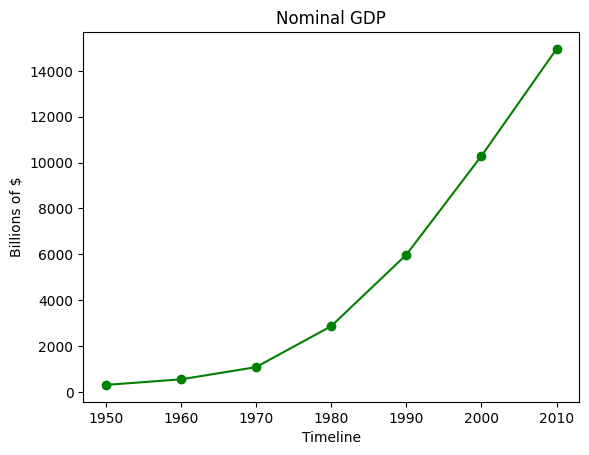

In [16]:
from matplotlib import pyplot as plt

years = [1950, 1960, 1970, 1980, 1990, 2000, 2010]
gdp = [300.2, 543.3, 1075.9, 2862.5, 5979.6, 10289.7, 14958.3]

# Create a line chart, years on x-axis, gdp on y-axis
plt.plot(years,gdp, color='green', marker='o', linestyle='solid')

# Add a title
plt.title("Nominal GDP")

# Add a label to the y-axis
plt.ylabel("Billions of $")
plt.xlabel("Timeline")

plt.show()


Lograr gráficos con una calidad profesional para su publicación es más complejo y escapa al alcance de este capítulo. Existen muchas maneras de personalizar los gráficos, por ejemplo, con etiquetas de ejes, estilos de línea y marcadores de puntos. En lugar de abordar todas estas opciones en detalle, utilizaremos algunas de ellas en nuestros ejemplos.

> Nota
Aunque no utilizaremos gran parte de esta funcionalidad, Matplotlib permite crear gráficos complejos dentro de otros gráficos, formatos sofisticados y visualizaciones interactivas. Consulta su documentación si deseas profundizar más allá de lo que se aborda en este libro.

## Gráficos de barras
Un gráfico de barras es una buena opción cuando se desea mostrar cómo varía una cantidad entre un conjunto discreto de elementos. Por ejemplo, la Figura 3-2 muestra cuántos Premios Óscar ganó cada una de varias películas:

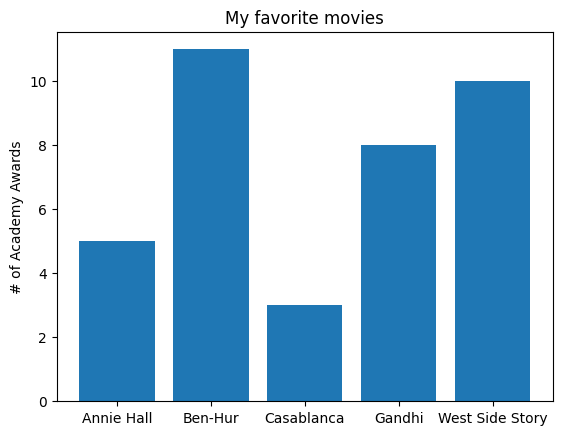

In [27]:
movies = ["Annie Hall", "Ben-Hur", "Casablanca", "Gandhi", "West Side Story"]
num_oscars = [5, 11, 3, 8, 10]

# plot bars with left x-coordinates [0,1,2,3,4], heights [num_oscars]
plt.bar(range(len(movies)), num_oscars)

plt.title("My favorite movies") # add a title
plt.ylabel("# of Academy Awards") # label the y-axis

# label x-axis with movie names at bar centers
plt.xticks(range(len(movies)), movies)

plt.show()


Un gráfico de barras también puede ser una buena opción para trazar histogramas de valores numéricos agrupados, como en la Figura 3-3 , para explorar visualmente cómo se distribuyen los valores :

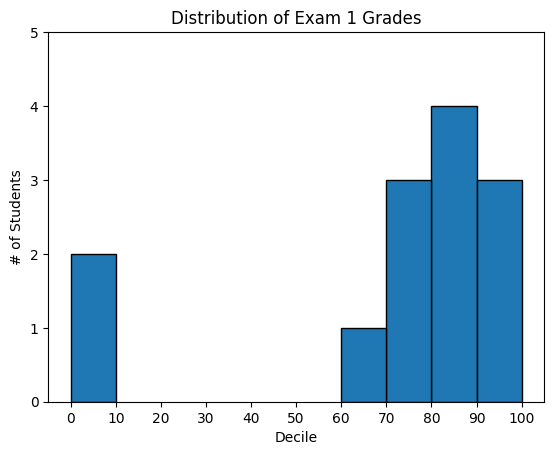

In [44]:
from collections import Counter
grades = [83, 95, 91, 87, 70, 0, 85, 82, 100, 67, 73, 77, 0]

# Bucket grades by decile, but put 100 in with the 90s
histogram = Counter(min(grade // 10 * 10, 90) for grade in grades)

plt.bar([x + 5 for x in histogram.keys()], histogram.values(), 10, edgecolor = (0,0,0))

plt.axis([-5, 105, 0, 5]) # x-axis from -5 to 105,
                          # y-axis from 0 to 5
plt.xticks([10 * i for i in range(11)])    # x-axis labels at 0, 10, ..., 100
plt.xlabel("Decile")
plt.ylabel("# of Students")
plt.title("Distribution of Exam 1 Grades")
plt.show()

El tercer argumento `plt.bar` especifica el ancho de la barra. En este caso, elegimos un ancho de 10 para que abarcara todo el decil. También desplazamos las barras 5 unidades a la derecha, de modo que, por ejemplo, la barra "10" (que corresponde al decil 10-20) tuviera su centro en 15 y, por lo tanto, ocupara el rango correcto. Además, añadimos un borde negro a cada barra para diferenciarlas visualmente.

La llamada `plt.axis` indica que queremos que el eje `x` varíe de `-5` a `105` (solo para dejar un poco de espacio a la izquierda y a la derecha), y que el eje y varíe de 0 a 5. Y la llamada coloca` plt.xticks` etiquetas del eje x en 0, 10, 20, ..., 100.

Sea prudente al usar `plt.axis`. Al crear gráficos de barras, se considera especialmente de mala práctica que el eje `y` no comience en 0, ya que esta es una manera fácil de engañar a la gente (Figura 3-4):

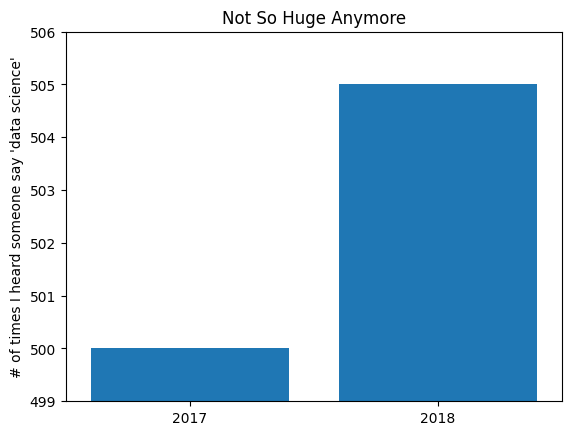

In [59]:
mentions = [500, 505]
years = [2017, 2018]

plt.bar(years, mentions, 0.8)
plt.xticks(years)
plt.ylabel("# of times I heard someone say 'data science'")

# if you don't do this, matplotlib will label the x-axis 0, 1
# and then add a +2.013e3 off in the corner (bad matplotlib!)
plt.ticklabel_format(useOffset=False)

# misleading y-axis only shows the part above 500
plt.axis([2016.5, 2018.5, 499, 506])
# plt.title("Look at the 'Huge' Increase!")
# plt.show()

# En la Figura 3-5 , utilizamos ejes más sensatos y el resultado es mucho menos impresionante:
# plt.axis([2016.5, 2018.5, 0, 550])
plt.title("Not So Huge Anymore")
plt.show()

## Gráficos de líneas
Como ya vimos, podemos crear gráficos de líneas usando `plt.plot`. Estos son una buena opción para mostrar tendencias , como se ilustra en la Figura 3-6 :

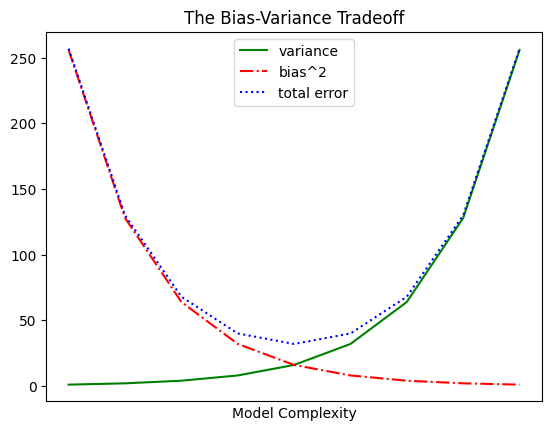

In [77]:
variance     = [1, 2, 4, 8, 16, 32, 64, 128, 256]
bias_squared = [256, 128, 64, 32, 16, 8, 4, 2, 1]
total_error = [x + y for x, y in zip(variance, bias_squared)]
xs = [i for i, _ in enumerate(variance)]

# We can make multiple calls to plt.plot
# to show multiple series on the same chart
plt.plot(xs, variance,  'g-', label='variance') # green solid line
plt.plot(xs, bias_squared, 'r-.', label='bias^2') # red dot-dashed line
plt.plot(xs, total_error, 'b:', label='total error') # blue dotted line

# Because we've assigned labels to each series,
# we can get a legend for free (loc=9 means "top center")
plt.legend(loc=9)
plt.xlabel("Model Complexity")
plt.xticks([])
plt.title("The Bias-Variance Tradeoff")
plt.show()

## Diagramas de dispersión
El diagrama de dispersión es la opción adecuada para visualizar la relación entre dos conjuntos de datos emparejados. Por ejemplo, la Figura 3-7 ilustra la relación entre el número de amigos que tienen sus usuarios y el número de minutos que pasan en el sitio cada día:

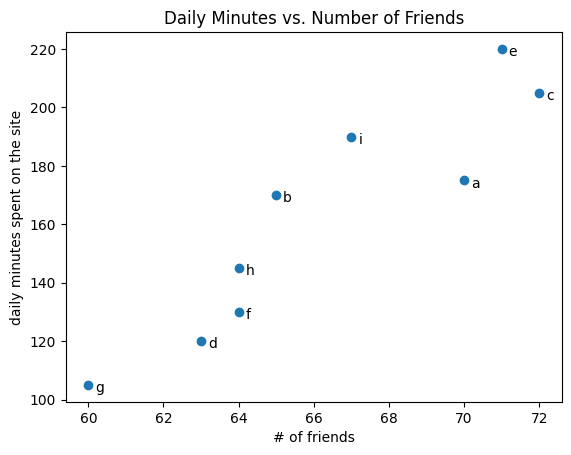

In [93]:
friends = [ 70,  65,  72,  63,  71,  64,  60,  64,  67]
minutes = [175, 170, 205, 120, 220, 130, 105, 145, 190]
labels =  ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

plt.scatter(friends, minutes)
# label each point
for label, friend_count, minute_count in zip(labels, friends, minutes):
    plt.annotate(label,
                xy=(friend_count, minute_count), #Put the label with its point
                xytext=(5, -5),                  # but slightly offset
                textcoords='offset points',
                )

plt.title("Daily Minutes vs. Number of Friends")
plt.xlabel("# of friends")
plt.ylabel("daily minutes spent on the site")
plt.show()

Si está dispersando variables comparables, podría obtener una imagen engañosa si deja que matplotlib elija la escala, como en la Figura 3-8 .

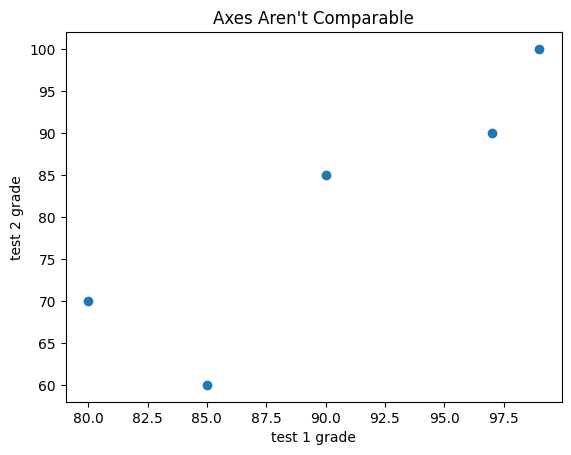

In [94]:
test_1_grades = [ 99, 90, 85, 97, 80]
test_2_grades = [100, 85, 60, 90, 70]

plt.scatter(test_1_grades, test_2_grades)
plt.title("Axes Aren't Comparable")
plt.xlabel("test 1 grade")
plt.ylabel("test 2 grade")
plt.show()

Si incluimos una llamada a `plt.axis("equal")`, el gráfico ( Figura 3-9 ) muestra con mayor precisión que la mayor parte de la variación ocurre en la prueba 2.

Con esto basta para empezar a practicar la visualización. Aprenderemos mucho más sobre visualización a lo largo del libro.

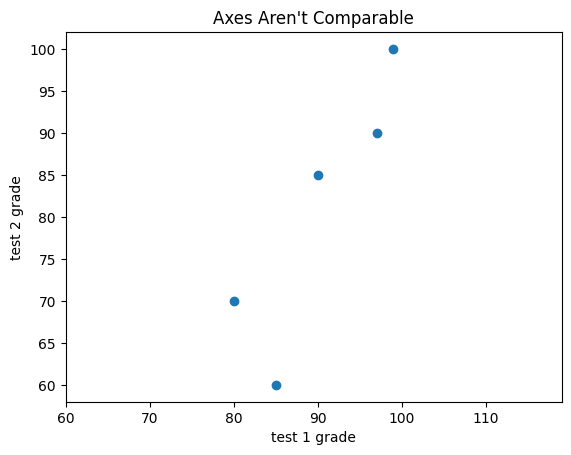

In [100]:
test_1_grades = [ 99, 90, 85, 97, 80]
test_2_grades = [100, 85, 60, 90, 70]

plt.scatter(test_1_grades, test_2_grades)
plt.title("Axes Aren't Comparable")
plt.axis("equal")
plt.xlabel("test 1 grade")
plt.ylabel("test 2 grade")
plt.show()

## Para una exploración más profunda

- [La galería de Matplotlib te dará una buena idea de las cosas que puedes hacer con Matplotlib (y cómo hacerlas).
- nacido en el mar esEstá basado en matplotlib y permite crear fácilmente visualizaciones más atractivas (y más complejas).
- Altair es un modelo más reciente.Librería de Python para crear visualizaciones declarativas.
- D3.js es un JavaScriptLibrería para crear visualizaciones interactivas sofisticadas para la web. Aunque no está escrita en Python, es muy utilizada y merece la pena familiarizarse con ella.
- Bokeh es una biblioteca que incorpora visualizaciones al estilo D3 a Python.